In [66]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 

warnings.filterwarnings('ignore')

In [67]:
df = pd.read_csv('insurance.csv')

In [68]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [69]:
df.shape

(1338, 7)

In [70]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [72]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [73]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [74]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

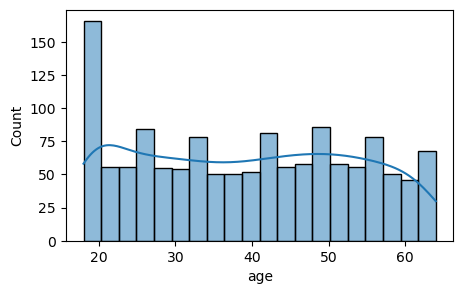

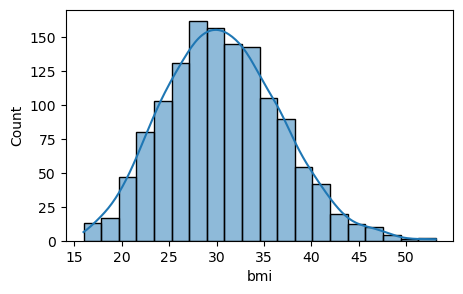

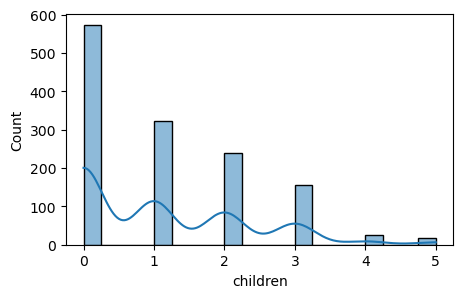

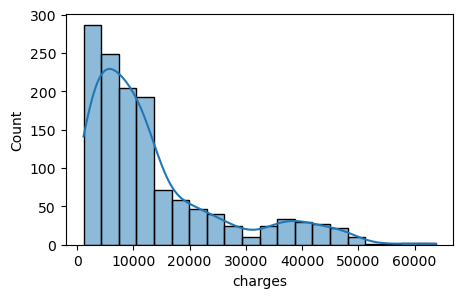

In [75]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde = True, bins = 20)

<Axes: xlabel='children', ylabel='count'>

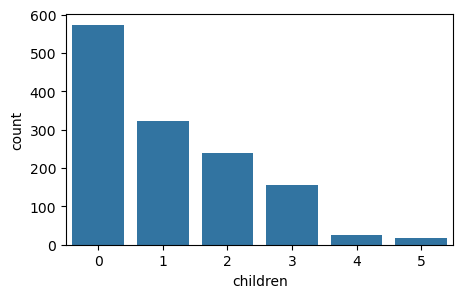

In [76]:
plt.figure(figsize = (5,3))
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

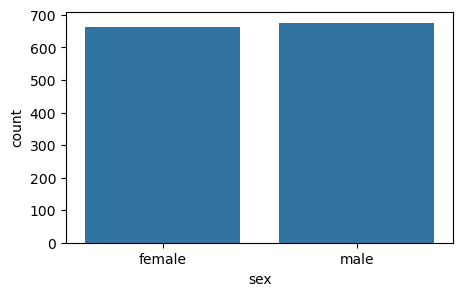

In [77]:
plt.figure(figsize = (5,3))
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

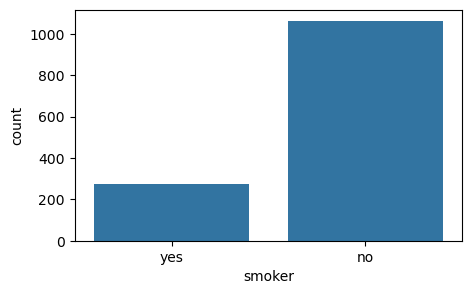

In [78]:
plt.figure(figsize = (5,3))
sns.countplot(x = df['smoker'])

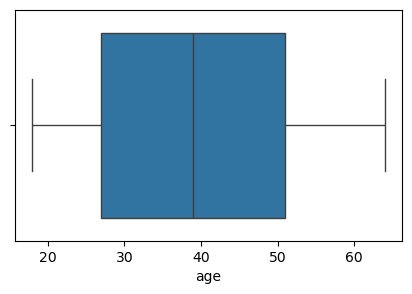

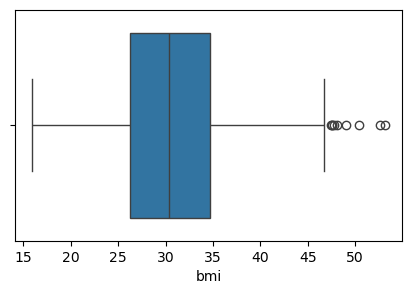

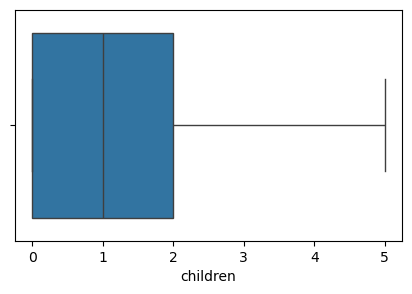

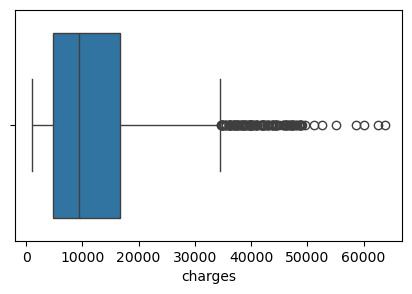

In [79]:
for col in numeric_columns:
    plt.figure(figsize = (5,3))
    sns.boxplot(x = df[col])

(array([0.5, 1.5, 2.5, 3.5]),
 [Text(0, 0.5, 'age'),
  Text(0, 1.5, 'bmi'),
  Text(0, 2.5, 'children'),
  Text(0, 3.5, 'charges')])

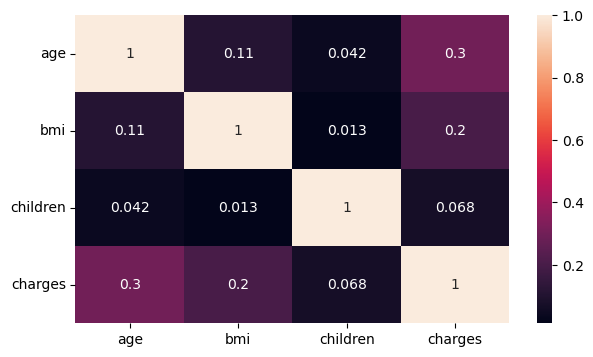

In [80]:
plt.figure(figsize = (7,4))
sns.heatmap(df.corr(numeric_only = True),annot = True)
plt.yticks(rotation = 0)

# Data Cleaning and Preprocessing

In [81]:
df_cleaned = df.copy()

In [82]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [83]:
df_cleaned.shape

(1338, 7)

In [84]:
df_cleaned.drop_duplicates(inplace = True)

In [85]:
df_cleaned.shape

(1337, 7)

In [86]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [87]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [88]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [89]:
df_cleaned['sex'] = df_cleaned['sex'].map({'male' : 0, "female" : 1})

In [90]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [91]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [92]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'yes': 1, 'no': 0})

In [93]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [94]:
df_cleaned.rename(columns={
    'sex' : 'is_female', 
    'smoker' : 'is_smoker'
},inplace = True)

In [95]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [96]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [98]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns = ['region'],
    drop_first = True,
    dtype = int
    
)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

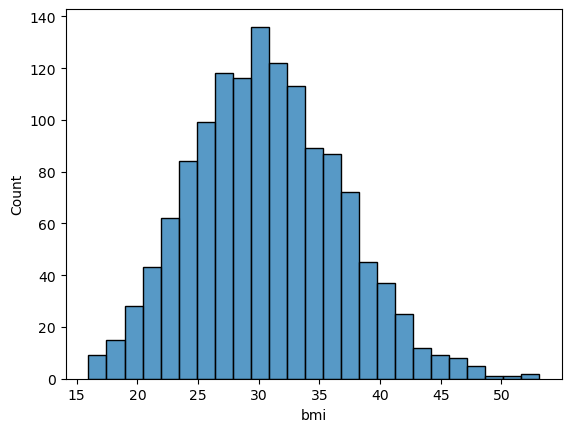

In [99]:
sns.histplot(df['bmi'])

In [103]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9, float('inf')], 
    labels = ['UnderWeight','Normal','OverWeight','Obese']
)
df_cleaned


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,1,OverWeight
1,18,0,33.770,1,0,1725.55230,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,1,0,0,OverWeight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,Obese
1334,18,1,31.920,0,0,2205.98080,0,0,0,Obese
1335,18,1,36.850,0,0,1629.83350,0,1,0,Obese
1336,21,1,25.800,0,0,2007.94500,0,0,1,OverWeight


In [104]:
df_cleaned = pd.get_dummies( 
    df_cleaned,
    columns = ['bmi_category'],
    drop_first = True,
    dtype = int
    )

In [105]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,1,0,1,0
1,18,0,33.770,1,0,1725.55230,0,1,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,1,0,0,0,1
3,33,0,22.705,0,0,21984.47061,1,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,1,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,1,0,1,0


In [107]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_OverWeight', 'bmi_category_Obese'],
      dtype='object')

In [109]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [110]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_OverWeight,bmi_category_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,1,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,1,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,1,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,1,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,1,0,0,0,1,0


In [113]:
from scipy.stats import pearsonr

# -----------------------------------------
# Pearson Correlation Calculation
# -----------------------------------------

# List of features to check against target
selected_features = [
    'age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_OverWeight', 'bmi_category_Obese'
]
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns = ['Feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending = False)

,Feature,Pearson Correlation
5,charges,1.000000
4,is_smoker,0.787234
0,age,0.298308
2,bmi,0.198401
11,bmi_category_Obese,0.197659
7,region_southeast,0.073578
3,children,0.067389
6,region_northwest,-0.038695
8,region_southwest,-0.043637
1,is_female,-0.058044


In [114]:
cat_features = [
       'age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_OverWeight', 'bmi_category_Obese'
]


In [117]:
from scipy.stats import chi2_contingency 
import pandas as pd 
alpha = 0.5 
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q = 4, labels = False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p-value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T 
chi2_df = chi2_df.sort_values(by='p-value') 
chi2_df

,chi2_statistic,p-value,Decision
age,1509.13025,0.0,Reject Null (Keep Feature)
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
children,138.659313,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Reject Null (Keep Feature)
bmi_category_Normal,4.263673,0.234364,Reject Null (Keep Feature)
bmi_category_OverWeight,4.201575,0.240504,Reject Null (Keep Feature)
bmi,1661.030978,0.359475,Reject Null (Keep Feature)


In [119]:
final_df = df_cleaned[['age','is_female','bmi','children','is_smoker','charges','region_southeast','bmi_category_Obese']]

In [120]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,1,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,1,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,0,1
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,0,1
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,1,1
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,0,0
